In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready!")

Environment ready!


In [38]:
import os

file_path = "../data/raw/PS_20174392719_1491204439457_log.csv"

print("File exists:", os.path.exists(file_path))

File exists: True


In [39]:
df_sample = pd.read_csv(file_path, nrows=10000)

print("Sample shape:", df_sample.shape)
print("\nColumns:")
print(df_sample.columns.tolist())

Sample shape: (10000, 11)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [40]:
df_sample.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [41]:
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            10000 non-null  int64  
 1   type            10000 non-null  str    
 2   amount          10000 non-null  float64
 3   nameOrig        10000 non-null  str    
 4   oldbalanceOrg   10000 non-null  float64
 5   newbalanceOrig  10000 non-null  float64
 6   nameDest        10000 non-null  str    
 7   oldbalanceDest  10000 non-null  float64
 8   newbalanceDest  10000 non-null  float64
 9   isFraud         10000 non-null  int64  
 10  isFlaggedFraud  10000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 1.1 MB


In [42]:
print("Transaction types:")
print(df_sample["type"].value_counts())

print("\nFraud distribution:")
print(df_sample["isFraud"].value_counts())

print("\nFraud percentage:")
print(df_sample["isFraud"].mean() * 100)

Transaction types:
type
PAYMENT     5465
CASH_IN     1949
CASH_OUT    1321
TRANSFER     921
DEBIT        344
Name: count, dtype: int64

Fraud distribution:
isFraud
0    9932
1      68
Name: count, dtype: int64

Fraud percentage:
0.6799999999999999


In [43]:
print("Number of unique senders:", df_sample["nameOrig"].nunique())
print("Number of unique receivers:", df_sample["nameDest"].nunique())
print("Number of time steps:", df_sample["step"].nunique())

Number of unique senders: 10000
Number of unique receivers: 6397
Number of time steps: 7


In [44]:
print(df_sample.groupby("type")["isFraud"].agg(["count", "sum", "mean"]))

          count  sum      mean
type                          
CASH_IN    1949    0  0.000000
CASH_OUT   1321   35  0.026495
DEBIT       344    0  0.000000
PAYMENT    5465    0  0.000000
TRANSFER    921   33  0.035831


In [45]:
import os

file_size_mb = os.path.getsize(file_path) / (1024 ** 2)

print(f"File size: {file_size_mb:.1f} MB")

File size: 470.7 MB


In [46]:
with open(file_path, "r", encoding="utf-8") as f:
    total_rows = sum(1 for _ in f) - 1

print(f"Total transactions: {total_rows:,}")

Total transactions: 6,362,620


In [47]:
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print(f"Memory used: {df.memory_usage(deep=True).sum() / (1024**3):.2f} GB")

Shape: (6362620, 11)
Memory used: 0.69 GB


In [48]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [49]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [50]:
fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)
print("\nFraud percentage:")
print(df["isFraud"].mean() * 100)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage:
0.12908204481801522


In [51]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [52]:
fraud_by_type = df.groupby("type")["isFraud"].agg(
    transactions="count",
    fraud_cases="sum",
    fraud_rate="mean"
)

fraud_by_type["fraud_rate"] *= 100

fraud_by_type

,transactions,fraud_cases,fraud_rate
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237500,4116,0.183955
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000
TRANSFER,532909,4097,0.768799


In [53]:
print("Minimum step:", df["step"].min())
print("Maximum step:", df["step"].max())
print("Unique steps:", df["step"].nunique())

Minimum step: 1
Maximum step: 743
Unique steps: 743


In [54]:
df["balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

df["amount_to_balance_ratio"] = (
    df["amount"] / (df["oldbalanceOrg"] + 1)
)

df["dest_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

df["hour"] = df["step"] % 24

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_change,amount_to_balance_ratio,dest_balance_change,hour
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.057834,0.0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.087731,0.0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.994505,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,0.994505,-21182.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.280788,0.0,1


In [55]:
df[
    [
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "balance_change",
        "amount_to_balance_ratio",
        "dest_balance_change",
        "hour"
    ]
].head(10)

,amount,oldbalanceOrg,newbalanceOrig,balance_change,amount_to_balance_ratio,dest_balance_change,hour
0,9839.64,170136.00,160296.36,9839.64,0.057834,0.00,1
1,1864.28,21249.00,19384.72,1864.28,0.087731,0.00,1
2,181.00,181.00,0.00,181.00,0.994505,0.00,1
3,181.00,181.00,0.00,181.00,0.994505,-21182.00,1
4,11668.14,41554.00,29885.86,11668.14,0.280788,0.00,1
5,7817.71,53860.00,46042.29,7817.71,0.145146,0.00,1
6,7107.77,183195.00,176087.23,7107.77,0.038799,0.00,1
7,7861.64,176087.23,168225.59,7861.64,0.044646,0.00,1
8,4024.36,2671.00,0.00,2671.00,1.506123,0.00,1
9,5337.77,41720.00,36382.23,5337.77,0.127940,-1549.21,1


In [56]:
# Make sure transactions are in chronological order
df = df.sort_values("step").reset_index(drop=True)

# Number of previous transactions by the sender
df["sender_txn_count_before"] = (
    df.groupby("nameOrig").cumcount()
)

# Cumulative amount BEFORE the current transaction
sender_amount_sum = (
    df.groupby("nameOrig")["amount"].cumsum() - df["amount"]
)

# Average previous transaction amount
df["sender_avg_amount_before"] = (
    sender_amount_sum /
    df["sender_txn_count_before"].replace(0, np.nan)
)

df["sender_avg_amount_before"] = (
    df["sender_avg_amount_before"].fillna(0)
)

# Number of previous transactions involving this recipient
df["recipient_txn_count_before"] = (
    df.groupby("nameDest").cumcount()
)

# Number of previous transactions between this sender and recipient
df["sender_recipient_count_before"] = (
    df.groupby(["nameOrig", "nameDest"]).cumcount()
)

df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_change,amount_to_balance_ratio,dest_balance_change,hour,sender_txn_count_before,sender_avg_amount_before,recipient_txn_count_before,sender_recipient_count_before
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0,9839.64,0.057834,0.00,1,0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0,1864.28,0.087731,0.00,1,0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0,181.00,0.994505,0.00,1,0,0.0,0,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0,181.00,0.994505,-21182.00,1,0,0.0,0,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0,11668.14,0.280788,0.00,1,0,0.0,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0,7817.71,0.145146,0.00,1,0,0.0,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0,7107.77,0.038799,0.00,1,0,0.0,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0,7861.64,0.044646,0.00,1,0,0.0,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0,2671.00,1.506123,0.00,1,0,0.0,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0,5337.77,0.127940,-1549.21,1,0,0.0,0,0


In [57]:
df["amount_vs_user_avg"] = (
    df["amount"] /
    (df["sender_avg_amount_before"] + 1)
)

df[
    [
        "amount",
        "sender_txn_count_before",
        "sender_avg_amount_before",
        "amount_vs_user_avg",
        "recipient_txn_count_before",
        "sender_recipient_count_before",
        "isFraud"
    ]
].head(20)

,amount,sender_txn_count_before,sender_avg_amount_before,amount_vs_user_avg,recipient_txn_count_before,sender_recipient_count_before,isFraud
0,9839.64,0,0.0,9839.64,0,0,0
1,1864.28,0,0.0,1864.28,0,0,0
2,181.00,0,0.0,181.00,0,0,1
3,181.00,0,0.0,181.00,0,0,1
4,11668.14,0,0.0,11668.14,0,0,0
5,7817.71,0,0.0,7817.71,0,0,0
6,7107.77,0,0.0,7107.77,0,0,0
7,7861.64,0,0.0,7861.64,0,0,0
8,4024.36,0,0.0,4024.36,0,0,0
9,5337.77,0,0.0,5337.77,0,0,0


In [58]:
print(
    df["sender_txn_count_before"].value_counts().sort_index().head(10)
)

sender_txn_count_before
0    6353307
1       9298
2         15
Name: count, dtype: int64


In [59]:
print(
    "Transactions with previous sender history:",
    (df["sender_txn_count_before"] > 0).sum()
)

Transactions with previous sender history: 9313


In [60]:
df[df["sender_txn_count_before"] > 0][
    [
        "step",
        "amount",
        "nameOrig",
        "sender_txn_count_before",
        "sender_avg_amount_before",
        "amount_vs_user_avg",
        "isFraud"
    ]
].head(10)

,step,amount,nameOrig,sender_txn_count_before,sender_avg_amount_before,amount_vs_user_avg,isFraud
115385,11,17670.78,C1709295811,1,497725.93,0.035503,0
146871,12,127216.34,C44568807,1,6107.51,20.826084,0
148517,12,4611.17,C260230637,1,12712.93,0.362686,0
196159,13,2745.21,C745009740,1,41726.55,0.065789,0
208603,13,220681.45,C1842781381,1,4231.32,52.141958,0
208779,13,287316.97,C199116739,1,11813.50,24.319012,0
235870,14,65072.01,C779875094,1,31395.75,2.072572,0
236407,14,482750.80,C189326840,1,130477.15,3.699859,0
272911,15,822.43,C1250194175,1,452480.26,0.001818,0
281403,15,557739.04,C746558292,1,149585.24,3.728545,0


In [61]:
df["sender_txns_same_step"] = (
    df.groupby(["nameOrig", "step"])["nameOrig"]
      .transform("count")
)

In [62]:
df["recipient_txns_same_step"] = (
    df.groupby(["nameDest", "step"])["nameDest"]
      .transform("count")
)

In [63]:
df["sender_velocity_before"] = (
    df.groupby(["nameOrig", "step"]).cumcount()
)

In [64]:
df["is_new_recipient"] = (
    df["recipient_txn_count_before"] == 0
).astype(int)

df["is_new_sender"] = (
    df["sender_txn_count_before"] == 0
).astype(int)

df["large_transaction"] = (
    df["amount"] > df["amount"].quantile(0.95)
).astype(int)

In [65]:
feature_columns = [
    "step",
    "type",
    "amount",
    "balance_change",
    "amount_to_balance_ratio",
    "sender_txn_count_before",
    "sender_avg_amount_before",
    "amount_vs_user_avg",
    "recipient_txn_count_before",
    "sender_recipient_count_before",
    "sender_txns_same_step",
    "recipient_txns_same_step",
    "sender_velocity_before",
    "is_new_recipient",
    "is_new_sender",
    "large_transaction",
    "isFraud"
]

df[feature_columns].head(20)

,step,type,amount,balance_change,amount_to_balance_ratio,sender_txn_count_before,sender_avg_amount_before,amount_vs_user_avg,recipient_txn_count_before,sender_recipient_count_before,sender_txns_same_step,recipient_txns_same_step,sender_velocity_before,is_new_recipient,is_new_sender,large_transaction,isFraud
0,1,PAYMENT,9839.64,9839.64,0.057834,0,0.0,9839.64,0,0,1,1,0,1,1,0,0
1,1,PAYMENT,1864.28,1864.28,0.087731,0,0.0,1864.28,0,0,1,1,0,1,1,0,0
2,1,TRANSFER,181.00,181.00,0.994505,0,0.0,181.00,0,0,1,1,0,1,1,0,1
3,1,CASH_OUT,181.00,181.00,0.994505,0,0.0,181.00,0,0,1,1,0,1,1,0,1
4,1,PAYMENT,11668.14,11668.14,0.280788,0,0.0,11668.14,0,0,1,1,0,1,1,0,0
5,1,PAYMENT,7817.71,7817.71,0.145146,0,0.0,7817.71,0,0,1,1,0,1,1,0,0
6,1,PAYMENT,7107.77,7107.77,0.038799,0,0.0,7107.77,0,0,1,1,0,1,1,0,0
7,1,PAYMENT,7861.64,7861.64,0.044646,0,0.0,7861.64,0,0,1,1,0,1,1,0,0
8,1,PAYMENT,4024.36,2671.00,1.506123,0,0.0,4024.36,0,0,1,1,0,1,1,0,0
9,1,DEBIT,5337.77,5337.77,0.127940,0,0.0,5337.77,0,0,1,6,0,1,1,0,0


In [66]:
numeric_features = [
    "amount",
    "balance_change",
    "amount_to_balance_ratio",
    "sender_txn_count_before",
    "sender_avg_amount_before",
    "amount_vs_user_avg",
    "recipient_txn_count_before",
    "sender_recipient_count_before",
    "sender_txns_same_step",
    "recipient_txns_same_step",
    "sender_velocity_before"
]

df.groupby("isFraud")[numeric_features].median().T

isFraud,0,1
amount,74684.720000,441423.440000
balance_change,0.000000,436317.490000
amount_to_balance_ratio,6.511566,0.999998
sender_txn_count_before,0.000000,0.000000
sender_avg_amount_before,0.000000,0.000000
amount_vs_user_avg,74363.480000,438394.670000
recipient_txn_count_before,2.000000,0.000000
sender_recipient_count_before,0.000000,0.000000
sender_txns_same_step,1.000000,1.000000
recipient_txns_same_step,1.000000,1.000000


In [67]:
print("Fraud rate by sender velocity:")
print(
    df.groupby("sender_velocity_before")["isFraud"]
      .agg(["count", "sum", "mean"])
      .sort_values("count", ascending=False)
      .head(10)
)

Fraud rate by sender velocity:
                          count   sum      mean
sender_velocity_before                         
0                       6362573  8213  0.001291
1                            47     0  0.000000


In [68]:
print("Fraud rate by new recipient:")
print(
    df.groupby("is_new_recipient")["isFraud"]
      .agg(["count", "sum", "mean"])
)

Fraud rate by new recipient:
                    count   sum      mean
is_new_recipient                         
0                 3640258  3039  0.000835
1                 2722362  5174  0.001901


In [69]:
print("Fraud rate by transaction type:")
print(
    df.groupby("type")["isFraud"]
      .agg(["count", "sum", "mean"])
)

Fraud rate by transaction type:
            count   sum      mean
type                             
CASH_IN   1399284     0  0.000000
CASH_OUT  2237500  4116  0.001840
DEBIT       41432     0  0.000000
PAYMENT   2151495     0  0.000000
TRANSFER   532909  4097  0.007688


In [70]:
model_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balance_change",
    "amount_to_balance_ratio",
    "recipient_txn_count_before",
    "sender_recipient_count_before",
    "is_new_recipient",
    "type"
]

target = "isFraud"

model_df = df[model_features + [target]].copy()

print("Shape:", model_df.shape)
model_df.head()

Shape: (6362620, 13)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_change,amount_to_balance_ratio,recipient_txn_count_before,sender_recipient_count_before,is_new_recipient,type,isFraud
0,1,9839.64,170136.0,160296.36,0.0,0.0,9839.64,0.057834,0,0,1,PAYMENT,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,1864.28,0.087731,0,0,1,PAYMENT,0
2,1,181.00,181.0,0.00,0.0,0.0,181.00,0.994505,0,0,1,TRANSFER,1
3,1,181.00,181.0,0.00,21182.0,0.0,181.00,0.994505,0,0,1,CASH_OUT,1
4,1,11668.14,41554.0,29885.86,0.0,0.0,11668.14,0.280788,0,0,1,PAYMENT,0


In [71]:
model_df = pd.get_dummies(
    model_df,
    columns=["type"],
    drop_first=False,
    dtype=int
)

print("New shape:", model_df.shape)
print(model_df.columns.tolist())

New shape: (6362620, 17)
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_change', 'amount_to_balance_ratio', 'recipient_txn_count_before', 'sender_recipient_count_before', 'is_new_recipient', 'isFraud', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [72]:
X = model_df.drop(columns=["isFraud"])
y = model_df["isFraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFraud cases:", y.sum())
print("Legitimate cases:", (y == 0).sum())

X shape: (6362620, 16)
y shape: (6362620,)

Fraud cases: 8213
Legitimate cases: 6354407


In [73]:
split_step = int(df["step"].max() * 0.8)

print("Maximum step:", df["step"].max())
print("Training until step:", split_step)

Maximum step: 743
Training until step: 594


In [74]:
train_mask = df["step"] <= split_step
test_mask = df["step"] > split_step

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining fraud cases:", y_train.sum())
print("Testing fraud cases:", y_test.sum())

Training samples: 6239040
Testing samples: 123580

Training fraud cases: 6559
Testing fraud cases: 1654


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Random Forest training complete!")

Training Random Forest...
Random Forest training complete!


In [76]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_pred = (rf_prob >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("PR-AUC:", average_precision_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

ROC-AUC: 1.0
PR-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    121926
           1       1.00      1.00      1.00      1654

    accuracy                           1.00    123580
   macro avg       1.00      1.00      1.00    123580
weighted avg       1.00      1.00      1.00    123580


Confusion Matrix:
[[121926      0]
 [     0   1654]]


In [77]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
7,amount_to_balance_ratio,0.301222
6,balance_change,0.285116
3,newbalanceOrig,0.128488
2,oldbalanceOrg,0.080499
1,amount,0.052156
14,type_PAYMENT,0.044753
15,type_TRANSFER,0.034947
5,newbalanceDest,0.017518
4,oldbalanceDest,0.013320
11,type_CASH_IN,0.013262


In [78]:
feature_importance.head(10)

,feature,importance
7,amount_to_balance_ratio,0.301222
6,balance_change,0.285116
3,newbalanceOrig,0.128488
2,oldbalanceOrg,0.080499
1,amount,0.052156
14,type_PAYMENT,0.044753
15,type_TRANSFER,0.034947
5,newbalanceDest,0.017518
4,oldbalanceDest,0.013320
11,type_CASH_IN,0.013262


In [79]:
print(
    df.groupby("isFraud")[
        [
            "amount",
            "oldbalanceOrg",
            "newbalanceOrig",
            "balance_change",
            "amount_to_balance_ratio"
        ]
    ].median()
)

            amount  oldbalanceOrg  newbalanceOrig  balance_change  \
isFraud                                                             
0         74684.72       14069.00             0.0            0.00   
1        441423.44      438983.45             0.0       436317.49   

         amount_to_balance_ratio  
isFraud                           
0                       6.511566  
1                       0.999998  


In [80]:
# Separate legitimate and fraudulent training transactions
X_train_fraud = X_train[y_train == 1]
y_train_fraud = y_train[y_train == 1]

X_train_legit = X_train[y_train == 0]
y_train_legit = y_train[y_train == 0]

print("Fraud training rows:", len(X_train_fraud))
print("Legitimate training rows:", len(X_train_legit))

Fraud training rows: 6559
Legitimate training rows: 6232481


In [81]:
# Sample 500,000 legitimate transactions
X_train_legit_sample = X_train_legit.sample(
    n=500_000,
    random_state=42
)

y_train_legit_sample = y_train_legit.loc[
    X_train_legit_sample.index
]

# Combine fraud + legitimate samples
X_xgb_train = pd.concat(
    [X_train_fraud, X_train_legit_sample]
)

y_xgb_train = pd.concat(
    [y_train_fraud, y_train_legit_sample]
)

# Shuffle the resulting training set
shuffle_idx = X_xgb_train.sample(
    frac=1,
    random_state=42
).index

X_xgb_train = X_xgb_train.loc[shuffle_idx]
y_xgb_train = y_xgb_train.loc[shuffle_idx]

print("Final XGBoost training shape:", X_xgb_train.shape)
print("Fraud cases:", y_xgb_train.sum())
print("Legitimate cases:", (y_xgb_train == 0).sum())

Final XGBoost training shape: (506559, 16)
Fraud cases: 6559
Legitimate cases: 500000


In [82]:
scale_pos_weight = (
    (y_xgb_train == 0).sum() /
    (y_xgb_train == 1).sum()
)

print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 76.23113279463333


In [83]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    X_xgb_train,
    y_xgb_train
)

print("XGBoost training complete!")

Training XGBoost...
XGBoost training complete!


In [84]:
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_pred = (xgb_prob >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print("PR-AUC:", average_precision_score(y_test, xgb_prob))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

ROC-AUC: 0.9999980785022715
PR-AUC: 0.9998488804368182

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    121926
           1       1.00      1.00      1.00      1654

    accuracy                           1.00    123580
   macro avg       1.00      1.00      1.00    123580
weighted avg       1.00      1.00      1.00    123580


Confusion Matrix:
[[121924      2]
 [     1   1653]]


In [85]:
from sklearn.metrics import precision_score, recall_score, f1_score

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, xgb_prob)
    ],
    "Precision": [rf_precision, xgb_precision],
    "Recall": [rf_recall, xgb_recall],
    "F1": [rf_f1, xgb_f1]
})

comparison

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
1,XGBoost,0.999998,0.999849,0.998792,0.999395,0.999093


In [86]:
from sklearn.ensemble import IsolationForest

# Use legitimate training transactions only
X_iforest_legit = X_train[y_train == 0]

# Sample normal behaviour for anomaly detection
X_iforest_train = X_iforest_legit.sample(
    n=300_000,
    random_state=42
)

print("Isolation Forest training samples:", len(X_iforest_train))

Isolation Forest training samples: 300000


In [87]:
isolation_model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest...")

isolation_model.fit(X_iforest_train)

print("Isolation Forest training complete!")

Training Isolation Forest...
Isolation Forest training complete!


In [88]:
anomaly_score = -isolation_model.decision_function(X_test)

print("Minimum anomaly score:", anomaly_score.min())
print("Maximum anomaly score:", anomaly_score.max())

Minimum anomaly score: -0.21101257170489174
Maximum anomaly score: 0.15026810010764302


In [89]:
anomaly_results = pd.DataFrame({
    "anomaly_score": anomaly_score,
    "isFraud": y_test.values
})

anomaly_results.groupby("isFraud")["anomaly_score"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,121926.0,-0.155290,0.048444,-0.211013,-0.194122,-0.168983,-0.130885,0.150268
1,1654.0,-0.047214,0.073580,-0.202423,-0.092977,-0.044763,0.008093,0.132490


In [90]:
if_roc_auc = roc_auc_score(
    y_test,
    anomaly_score
)

if_pr_auc = average_precision_score(
    y_test,
    anomaly_score
)

print("Isolation Forest ROC-AUC:", if_roc_auc)
print("Isolation Forest PR-AUC:", if_pr_auc)

Isolation Forest ROC-AUC: 0.8836576340504749
Isolation Forest PR-AUC: 0.16308526832112918


In [91]:
anomaly_threshold = np.percentile(anomaly_score, 99)

anomaly_flag = (
    anomaly_score >= anomaly_threshold
).astype(int)

print("Anomaly threshold:", anomaly_threshold)
print("Transactions flagged:", anomaly_flag.sum())
print("Actual fraud among flagged:", y_test[anomaly_flag == 1].sum())

Anomaly threshold: 0.017540532552121117
Transactions flagged: 1236
Actual fraud among flagged: 337


In [92]:
print(
    classification_report(
        y_test,
        anomaly_flag,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    121926
           1       0.27      0.20      0.23      1654

    accuracy                           0.98    123580
   macro avg       0.63      0.60      0.61    123580
weighted avg       0.98      0.98      0.98    123580



In [93]:
import shap

# Use a small sample for SHAP explanations
X_shap = X_test.sample(
    n=1000,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (1000, 16)


In [94]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1000, 16)


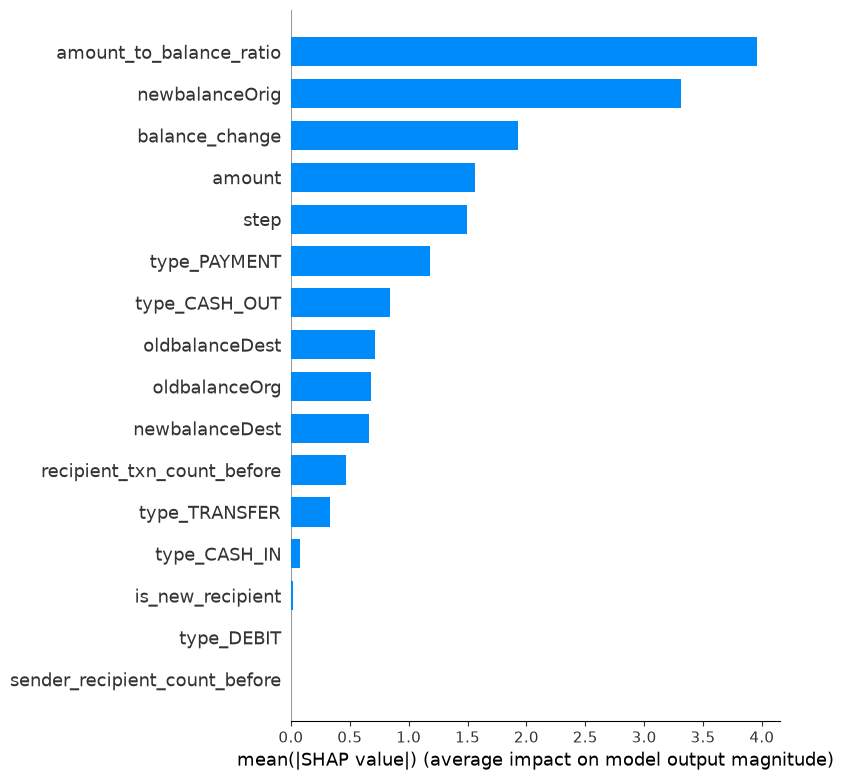

In [95]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

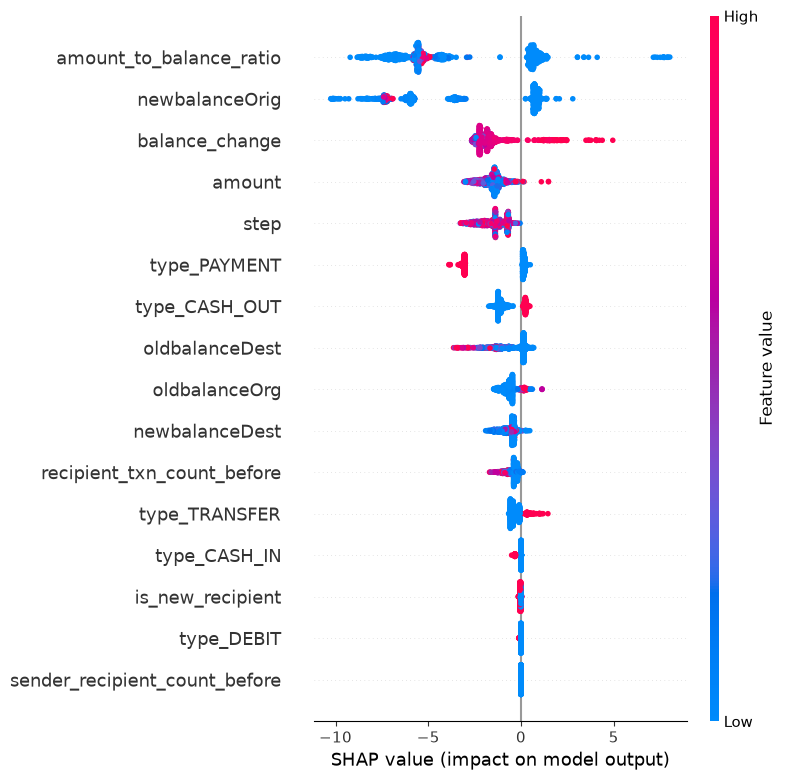

In [96]:
shap.summary_plot(
    shap_values,
    X_shap
)

In [97]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

joblib.dump(xgb_model, models_dir / "xgboost_fraud_model.pkl")
joblib.dump(isolation_model, models_dir / "isolation_forest_model.pkl")

print("Models saved successfully!")

Models saved successfully!


In [98]:
# Test fraud risk predictions

risk_test = X_test.copy()

risk_test["fraud_probability"] = xgb_prob
risk_test["anomaly_score"] = anomaly_score

risk_test["actual_fraud"] = y_test.values

risk_test[[
    "fraud_probability",
    "anomaly_score",
    "actual_fraud"
]].head(10)

,fraud_probability,anomaly_score,actual_fraud
6239040,7.593916e-06,-0.170120,0
6239041,2.988573e-06,-0.206991,0
6239042,4.283635e-06,-0.165448,0
6239043,1.183617e-06,-0.195137,0
6239044,1.183617e-06,-0.193669,0
6239045,9.750181e-07,-0.201262,0
6239046,2.171500e-07,-0.133893,0
6239047,1.183617e-06,-0.193669,0
6239048,2.068289e-04,-0.174927,0
6239049,1.099319e-05,-0.143813,0


In [99]:
print("LEGITIMATE TRANSACTIONS")
print(
    pd.Series(xgb_prob[y_test.values == 0])
    .describe(percentiles=[0.90, 0.95, 0.99, 0.999])
)

print("\nFRAUDULENT TRANSACTIONS")
print(
    pd.Series(xgb_prob[y_test.values == 1])
    .describe(percentiles=[0.01, 0.05, 0.10, 0.50])
)

LEGITIMATE TRANSACTIONS
count    1.219260e+05
mean     3.173850e-05
std      4.060779e-03
min      2.161860e-08
90%      1.865349e-05
95%      4.244057e-05
99%      1.371860e-04
99.9%    1.809929e-03
max      9.999899e-01
dtype: float64

FRAUDULENT TRANSACTIONS
count    1654.000000
mean        0.999516
std         0.019178
min         0.220057
1%          0.999844
5%          0.999978
10%         0.999987
50%         0.999998
max         1.000000
dtype: float64


In [101]:
import numpy as np

# Determine anomaly threshold using legitimate training data only
train_legit_anomaly_scores = -isolation_model.decision_function(X_iforest_train)

anomaly_threshold = np.quantile(train_legit_anomaly_scores, 0.99)

print("Anomaly threshold (top 1% of legitimate training data):")
print(anomaly_threshold)

Anomaly threshold (top 1% of legitimate training data):
2.304913762937288e-16


In [102]:
def calculate_risk(fraud_probability, anomaly_score):
    """
    Combines supervised fraud probability and anomaly score
    to assign a Low, Medium, or High risk level.
    """
    
    # High-confidence fraud
    if fraud_probability >= 0.50:
        return "HIGH"
    
    # Suspicious behaviour
    elif fraud_probability >= 0.01 or anomaly_score > anomaly_threshold:
        return "MEDIUM"
    
    # Low risk
    else:
        return "LOW"

In [103]:
# Test the risk engine on the first 10 test transactions

risk_results = pd.DataFrame({
    "fraud_probability": xgb_prob[:10],
    "anomaly_score": anomaly_score[:10],
    "actual_fraud": y_test.values[:10]
})

risk_results["risk_level"] = risk_results.apply(
    lambda row: calculate_risk(
        row["fraud_probability"],
        row["anomaly_score"]
    ),
    axis=1
)

risk_results

,fraud_probability,anomaly_score,actual_fraud,risk_level
0,7.593916e-06,-0.170120,0,LOW
1,2.988573e-06,-0.206991,0,LOW
2,4.283635e-06,-0.165448,0,LOW
3,1.183617e-06,-0.195137,0,LOW
4,1.183617e-06,-0.193669,0,LOW
5,9.750181e-07,-0.201262,0,LOW
6,2.171500e-07,-0.133893,0,LOW
7,1.183617e-06,-0.193669,0,LOW
8,2.068289e-04,-0.174927,0,LOW
9,1.099319e-05,-0.143813,0,LOW


In [104]:
# Select 10 actual fraudulent transactions from the test set

fraud_indices = np.where(y_test.values == 1)[0][:10]

fraud_results = pd.DataFrame({
    "fraud_probability": xgb_prob[fraud_indices],
    "anomaly_score": anomaly_score[fraud_indices],
    "actual_fraud": y_test.values[fraud_indices]
})

fraud_results["risk_level"] = fraud_results.apply(
    lambda row: calculate_risk(
        row["fraud_probability"],
        row["anomaly_score"]
    ),
    axis=1
)

fraud_results

,fraud_probability,anomaly_score,actual_fraud,risk_level
0,0.999999,-0.051918,1,HIGH
1,0.999990,-0.093670,1,HIGH
2,1.000000,-0.014308,1,HIGH
3,0.999998,-0.051484,1,HIGH
4,1.000000,0.026749,1,HIGH
5,0.999999,-0.005708,1,HIGH
6,1.000000,-0.003847,1,HIGH
7,0.999999,-0.043461,1,HIGH
8,1.000000,-0.039930,1,HIGH
9,0.999993,-0.082082,1,HIGH


In [105]:
# Apply the risk engine to the complete test set

risk_results_all = pd.DataFrame({
    "fraud_probability": xgb_prob,
    "anomaly_score": anomaly_score,
    "actual_fraud": y_test.values
})

risk_results_all["risk_level"] = risk_results_all.apply(
    lambda row: calculate_risk(
        row["fraud_probability"],
        row["anomaly_score"]
    ),
    axis=1
)

print("Risk distribution:")
print(risk_results_all["risk_level"].value_counts())

print("\nRisk distribution (%):")
print(
    risk_results_all["risk_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nActual fraud by risk level:")
print(
    pd.crosstab(
        risk_results_all["risk_level"],
        risk_results_all["actual_fraud"]
    )
)

Risk distribution:
risk_level
LOW       120367
HIGH        1655
MEDIUM      1558
Name: count, dtype: int64

Risk distribution (%):
risk_level
LOW       97.40
HIGH       1.34
MEDIUM     1.26
Name: proportion, dtype: float64

Actual fraud by risk level:
actual_fraud       0     1
risk_level                
HIGH               2  1653
LOW           120367     0
MEDIUM          1557     1


In [106]:
# Create human-readable SHAP explanations

def get_shap_reasons(row_index, top_n=4):
    shap_row = shap_values[row_index]
    feature_values = X_shap.iloc[row_index]

    explanation = pd.DataFrame({
        "feature": X_shap.columns,
        "shap_value": shap_row,
        "feature_value": feature_values.values
    })

    # Features with positive SHAP values push toward fraud
    explanation = explanation[
        explanation["shap_value"] > 0
    ].sort_values(
        "shap_value",
        ascending=False
    ).head(top_n)

    return explanation

In [107]:
get_shap_reasons(0)

,feature,shap_value,feature_value
3,newbalanceOrig,0.758829,0.0
11,type_CASH_IN,0.003398,0.0
13,type_DEBIT,0.000744,0.0


In [108]:
# Find a fraudulent transaction inside our SHAP sample

fraud_shap_positions = np.where(
    y_test.loc[X_shap.index].values == 1
)[0]

print("Fraudulent transactions in SHAP sample:", len(fraud_shap_positions))

if len(fraud_shap_positions) > 0:
    fraud_position = fraud_shap_positions[0]
    print("First fraud position:", fraud_position)
    print(get_shap_reasons(fraud_position, top_n=5))

Fraudulent transactions in SHAP sample: 15
First fraud position: 88
                    feature  shap_value  feature_value
7   amount_to_balance_ratio    8.028304       0.999998
6            balance_change    4.052667  417129.110000
3            newbalanceOrig    1.319745       0.000000
2             oldbalanceOrg    0.543949  417129.110000
12            type_CASH_OUT    0.246592       1.000000


In [109]:
def feature_reason(feature, value):
    reasons = {
        "amount_to_balance_ratio":
            "Transaction amount is very large relative to the sender's available balance.",
        
        "balance_change":
            "The sender's balance shows a significant change during the transaction.",
        
        "newbalanceOrig":
            "The sender's resulting balance is a strong contributor to the fraud prediction.",
        
        "oldbalanceOrg":
            "The sender's original balance contributes to the fraud risk.",
        
        "amount":
            "The transaction amount contributes significantly to the fraud prediction.",
        
        "type_CASH_OUT":
            "The transaction is a CASH_OUT, which contributes to higher fraud risk in this dataset.",
        
        "type_TRANSFER":
            "The transaction is a TRANSFER, which contributes to higher fraud risk in this dataset.",
        
        "oldbalanceDest":
            "The recipient's original balance contributes to the fraud prediction.",
        
        "newbalanceDest":
            "The recipient's resulting balance contributes to the fraud prediction.",
        
        "recipient_txn_count_before":
            "The recipient's previous transaction history contributes to the prediction.",
        
        "sender_recipient_count_before":
            "The previous transaction relationship between sender and recipient contributes to the prediction."
    }
    
    return reasons.get(
        feature,
        f"{feature} contributes to the fraud prediction."
    )

In [110]:
# Generate readable reasons for our fraudulent example

fraud_explanation = get_shap_reasons(fraud_position, top_n=5)

fraud_explanation["reason"] = fraud_explanation.apply(
    lambda row: feature_reason(
        row["feature"],
        row["feature_value"]
    ),
    axis=1
)

fraud_explanation[["feature", "shap_value", "reason"]]

,feature,shap_value,reason
7,amount_to_balance_ratio,8.028304,Transaction amount is very large relative to t...
6,balance_change,4.052667,The sender's balance shows a significant chang...
3,newbalanceOrig,1.319745,The sender's resulting balance is a strong con...
2,oldbalanceOrg,0.543949,The sender's original balance contributes to t...
12,type_CASH_OUT,0.246592,"The transaction is a CASH_OUT, which contribut..."


In [111]:
def prepare_transaction(
    step,
    amount,
    oldbalanceOrg,
    newbalanceOrig,
    oldbalanceDest,
    newbalanceDest,
    transaction_type,
    recipient_txn_count_before=0,
    sender_recipient_count_before=0
):
    # Engineered features
    balance_change = oldbalanceOrg - newbalanceOrig

    amount_to_balance_ratio = (
        amount / (oldbalanceOrg + 1)
    )

    is_new_recipient = int(
        recipient_txn_count_before == 0
    )

    # Create feature dictionary
    transaction = {
        "step": step,
        "amount": amount,
        "oldbalanceOrg": oldbalanceOrg,
        "newbalanceOrig": newbalanceOrig,
        "oldbalanceDest": oldbalanceDest,
        "newbalanceDest": newbalanceDest,
        "balance_change": balance_change,
        "amount_to_balance_ratio": amount_to_balance_ratio,
        "recipient_txn_count_before": recipient_txn_count_before,
        "sender_recipient_count_before": sender_recipient_count_before,
        "is_new_recipient": is_new_recipient,
        "type_CASH_IN": 0,
        "type_CASH_OUT": 0,
        "type_DEBIT": 0,
        "type_PAYMENT": 0,
        "type_TRANSFER": 0
    }

    # Activate the selected transaction type
    type_column = "type_" + transaction_type
    transaction[type_column] = 1

    # Return in exactly the same order as X
    return pd.DataFrame([transaction])[X.columns]

In [112]:
test_transaction = prepare_transaction(
    step=600,
    amount=100000,
    oldbalanceOrg=150000,
    newbalanceOrig=50000,
    oldbalanceDest=200000,
    newbalanceDest=300000,
    transaction_type="CASH_OUT"
)

test_transaction

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_change,amount_to_balance_ratio,recipient_txn_count_before,sender_recipient_count_before,is_new_recipient,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,600,100000,150000,50000,200000,300000,100000,0.666662,0,0,1,0,1,0,0,0


In [113]:
def analyze_transaction(transaction):
    # XGBoost fraud probability
    fraud_probability = xgb_model.predict_proba(transaction)[0, 1]

    # Isolation Forest anomaly score
    anomaly_score = -isolation_model.decision_function(transaction)[0]

    # Risk level
    risk_level = calculate_risk(
        fraud_probability,
        anomaly_score
    )

    return {
        "fraud_probability": fraud_probability,
        "anomaly_score": anomaly_score,
        "risk_level": risk_level
    }

In [114]:
result = analyze_transaction(test_transaction)

print("Fraud Probability:", result["fraud_probability"])
print("Anomaly Score:", result["anomaly_score"])
print("Risk Level:", result["risk_level"])

Fraud Probability: 1.4179972e-05
Anomaly Score: -0.12139815943916288
Risk Level: LOW


In [117]:
def explain_transaction(transaction, risk_level, top_n=4):
    explainer = shap.TreeExplainer(xgb_model)
    shap_values_transaction = explainer.shap_values(transaction)

    explanation = pd.DataFrame({
        "feature": transaction.columns,
        "shap_value": shap_values_transaction[0],
        "feature_value": transaction.iloc[0].values
    })

    # Only features that actually contribute toward fraud
    explanation = explanation[
        explanation["shap_value"] > 0
    ]

    # Don't show inactive transaction-type features
    type_features = [
        "type_CASH_IN",
        "type_CASH_OUT",
        "type_DEBIT",
        "type_PAYMENT",
        "type_TRANSFER"
    ]

    explanation = explanation[
        ~(
            explanation["feature"].isin(type_features)
            & (explanation["feature_value"] == 0)
        )
    ]

    explanation = explanation.sort_values(
        "shap_value",
        ascending=False
    ).head(top_n)

    explanation["reason"] = explanation.apply(
        lambda row: feature_reason(
            row["feature"],
            row["feature_value"]
        ),
        axis=1
    )

    # Don't show detailed reasons for low-risk transactions
    if risk_level == "LOW":
        return pd.DataFrame({
            "reason": ["No significant fraud indicators detected."]
        })

    return explanation[[
        "feature",
        "shap_value",
        "reason"
    ]]

In [118]:
explanation = explain_transaction(
    test_transaction,
    result["risk_level"]
)

explanation

,reason
0,No significant fraud indicators detected.


In [119]:
# Find a legitimate transaction that the model considers moderately suspicious

medium_candidates = np.where(
    (y_test.values == 0) &
    (xgb_prob >= 0.01) &
    (xgb_prob < 0.50)
)[0]

print("Medium-risk legitimate candidates:", len(medium_candidates))

if len(medium_candidates) > 0:
    idx = medium_candidates[0]
    
    original_index = X_test.index[idx]
    
    print("\nTest-set position:", idx)
    print("Original dataframe index:", original_index)
    print("Fraud probability:", xgb_prob[idx])
    
    print("\nOriginal transaction:")
    print(df.loc[
        original_index,
        [
            "step",
            "amount",
            "oldbalanceOrg",
            "newbalanceOrig",
            "oldbalanceDest",
            "newbalanceDest",
            "type",
            "recipient_txn_count_before",
            "sender_recipient_count_before"
        ]
    ])

Medium-risk legitimate candidates: 18

Test-set position: 26771
Original dataframe index: 6265811
Fraud probability: 0.014799465

Original transaction:
step                                 614
amount                           15403.9
oldbalanceOrg                    15416.0
newbalanceOrig                      12.1
oldbalanceDest                       0.0
newbalanceDest                       0.0
type                             PAYMENT
recipient_txn_count_before             0
sender_recipient_count_before          0
Name: 6265811, dtype: object


In [120]:
# Create a lightweight dataset for the Streamlit demo

demo_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "type",
    "recipient_txn_count_before",
    "sender_recipient_count_before",
    "isFraud"
]

demo_data = df.loc[X_test.index, demo_columns].sample(
    n=5000,
    random_state=42
)

demo_path = "../data/processed/demo_transactions.csv"

demo_data.to_csv(
    demo_path,
    index=False
)

print("Demo dataset created!")
print("Shape:", demo_data.shape)
print("Saved to:", demo_path)

Demo dataset created!
Shape: (5000, 10)
Saved to: ../data/processed/demo_transactions.csv
